In [67]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [68]:
fsm = xr.open_dataset("../data/processed/fsm2_sd_all.nc")
senorge = xr.open_dataset("../data/processed/senorge_all.nc")
snow = xr.open_dataset("../data/processed/snowpack_all.nc")

In [69]:
fsm_sd = fsm["snow_depth"]
senorge_sd = senorge["snow_depth"]
snow_sd = snow["HS_mod"]

In [70]:
start = "2024-09-01"
end = "2025-06-01"

fsm_sd = fsm_sd.sel(time=slice(start, end))
senorge_sd = senorge_sd.sel(time=slice(start, end))
snow_sd = snow_sd.sel(time=slice(start, end))

In [71]:
def compare_station(station_id, snow_sd, fsm_sd, senorge_sd):
    snow_point = snow_sd.sel(station=station_id)

    x0 = snow["x"].sel(station=station_id).item()
    y0 = snow["y"].sel(station=station_id).item()

    snow_series = snow_point
    fsm_series = fsm_sd.sel(x=x0, y=y0, method="nearest")
    senorge_series = senorge_sd.sel(x=x0, y=y0, method="nearest")

    snow_daily = snow_series.resample(time="1D").mean()

    snow_daily, fsm_series = xr.align(snow_daily, fsm_series, join="inner")
    snow_daily, senorge_series = xr.align(snow_daily, senorge_series, join="inner")

    return snow_daily, fsm_series, senorge_series

In [72]:
def metrics(model, reference):
    model, reference = xr.align(model, reference, join="inner")

    valid = np.isfinite(model) & np.isfinite(reference)
    model = model.where(valid, drop=True)
    reference = reference.where(valid, drop=True)

    diff = model - reference

    bias = float(diff.mean().values)
    rmse = float(np.sqrt((diff ** 2).mean().values))
    corr = float(xr.corr(model, reference, dim="time").values)

    return bias, rmse, corr

In [73]:
print("FSM2 attrs:", fsm_series.attrs)
print("seNorge attrs:", senorge_series.attrs)
print("SNOWPACK attrs:", snow_daily.attrs)

print("FSM2 min/max:", float(fsm_series.min()), float(fsm_series.max()))
print("seNorge min/max:", float(senorge_series.min()), float(senorge_series.max()))
print("SNOWPACK min/max:", float(snow_daily.min()), float(snow_daily.max()))

FSM2 attrs: {'Name': 'snow_depth', 'grid_mapping': 'UTM_Zone_33', 'name': 'snow_depth', 'units': 'mm', 'standard_name': 'snow_depth', 'longname': 'snow depth'}
seNorge attrs: {'grid_mapping': 'projection_info', 'name': 'sd', 'units': 'cm', 'standard_name': 'snow_depth', 'longname': 'snow depth'}
SNOWPACK attrs: {}
FSM2 min/max: 0.0 1840.0
seNorge min/max: 0.0 129.90000915527344
SNOWPACK min/max: 0.0 123.10125000000001


In [77]:
fsm_plot = fsm_series / 1000      # mm → m
senorge_plot = senorge_series / 100  # cm → m
snow_plot = snow_daily / 100      # cm → m

In [75]:
station_id = "VIR1000A"

snow_daily, fsm_series, senorge_series = compare_station(
    station_id, snow_sd, fsm_sd, senorge_sd
)

bias_fsm, rmse_fsm, corr_fsm = metrics(fsm_series, snow_daily)
bias_sen, rmse_sen, corr_sen = metrics(senorge_series, snow_daily)

print(f"Stasjon: {station_id}")
print("FSM2 vs SNOWPACK")
print(f"Bias: {bias_fsm:.3f}")
print(f"RMSE: {rmse_fsm:.3f}")
print(f"Corr: {corr_fsm:.3f}")

print("\nseNorge vs SNOWPACK")
print(f"Bias: {bias_sen:.3f}")
print(f"RMSE: {rmse_sen:.3f}")
print(f"Corr: {corr_sen:.3f}")


Stasjon: VIR1000A
FSM2 vs SNOWPACK
Bias: 628.629
RMSE: 815.844
Corr: 0.951

seNorge vs SNOWPACK
Bias: 7.422
RMSE: 12.164
Corr: 0.974


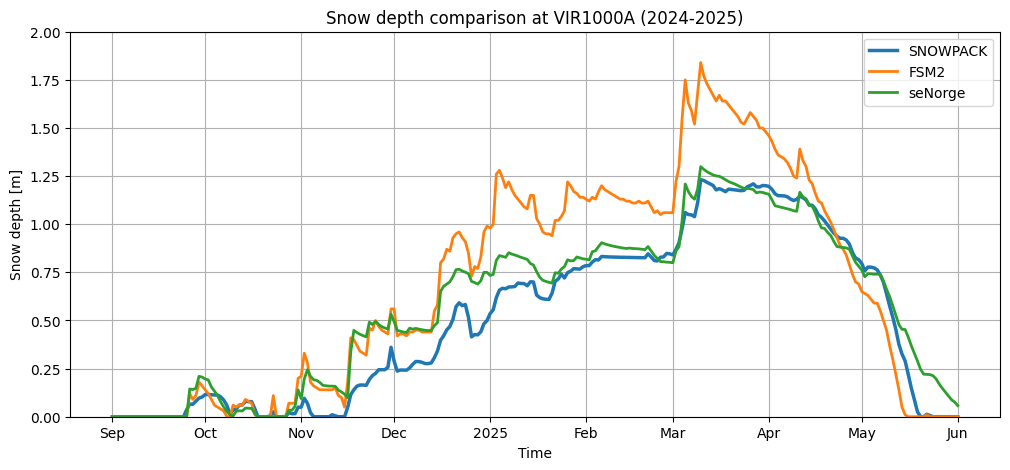

In [83]:
plt.figure(figsize=(12, 5))

snow_plot.plot(label="SNOWPACK", linewidth=2.5)
fsm_plot.plot(label="FSM2", linewidth=2)
senorge_plot.plot(label="seNorge", linewidth=2)

plt.title(f"Snow depth comparison at {station_id} (2024-2025)")
plt.ylabel("Snow depth [m]")
plt.ylim(0, 2)
plt.xlabel("Time")

plt.legend()
plt.grid(True)
plt.show()